<>:61: SyntaxWarning: invalid escape sequence '\d'
<>:64: SyntaxWarning: invalid escape sequence '\d'
<>:61: SyntaxWarning: invalid escape sequence '\d'
<>:64: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2170/1219975003.py:61: SyntaxWarning: invalid escape sequence '\d'
  loan_data['term'] = loan_data['term'].str.extract('(\d+)').astype(int)
/tmp/ipykernel_2170/1219975003.py:64: SyntaxWarning: invalid escape sequence '\d'
  loan_data['emp_length'] = loan_data['emp_length'].str.extract('(\d+)')


Dataset Loaded Successfully

First 5 Rows:
   loan_amnt       term int_rate  annual_inc emp_length home_ownership  \
0       5000  36 months   10.65%       24000   10 years           RENT   
1       2500  60 months   15.27%       30000     1 year           RENT   
2       2400  36 months   15.96%       12252   10 years            OWN   
3      10000  36 months   13.49%       49200    3 years       MORTGAGE   
4       3000  60 months   12.69%       80000    9 years           RENT   

              purpose grade  loan_status  
0         credit_card     B   Fully Paid  
1                 car     C  Charged Off  
2      small_business     C   Fully Paid  
3               other     B   Fully Paid  
4  debt_consolidation     B  Charged Off  

Dataset Shape:
(10, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   loan_amnt     

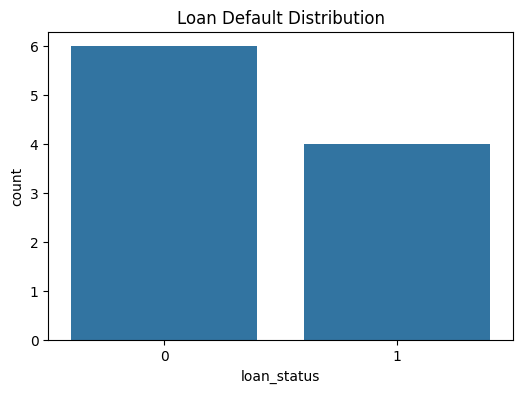

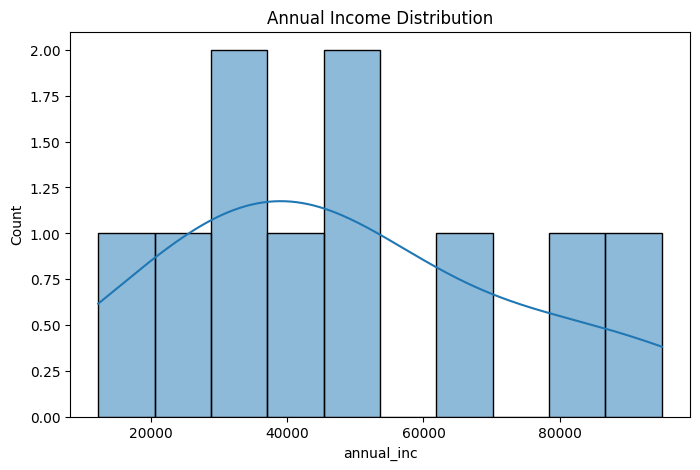

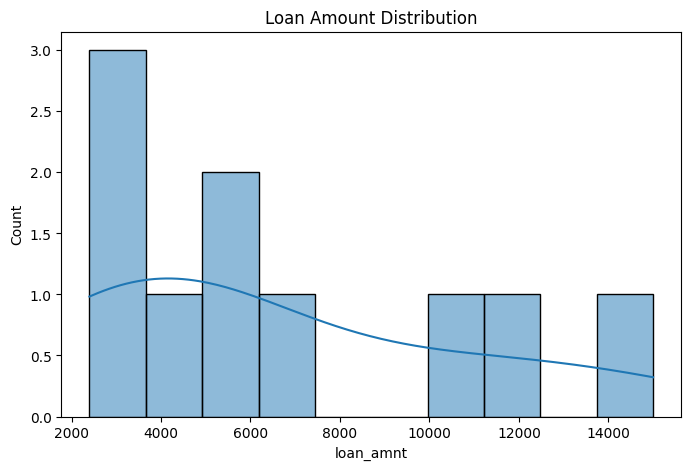

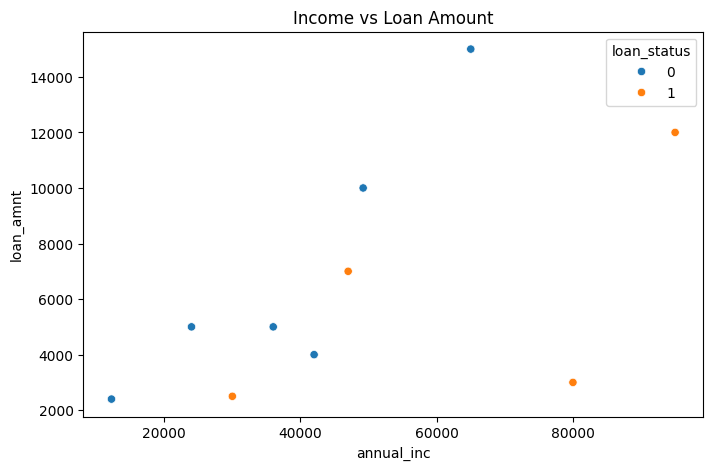

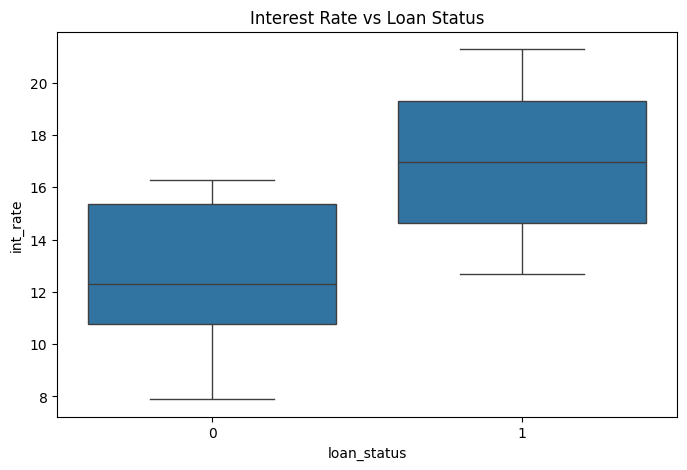

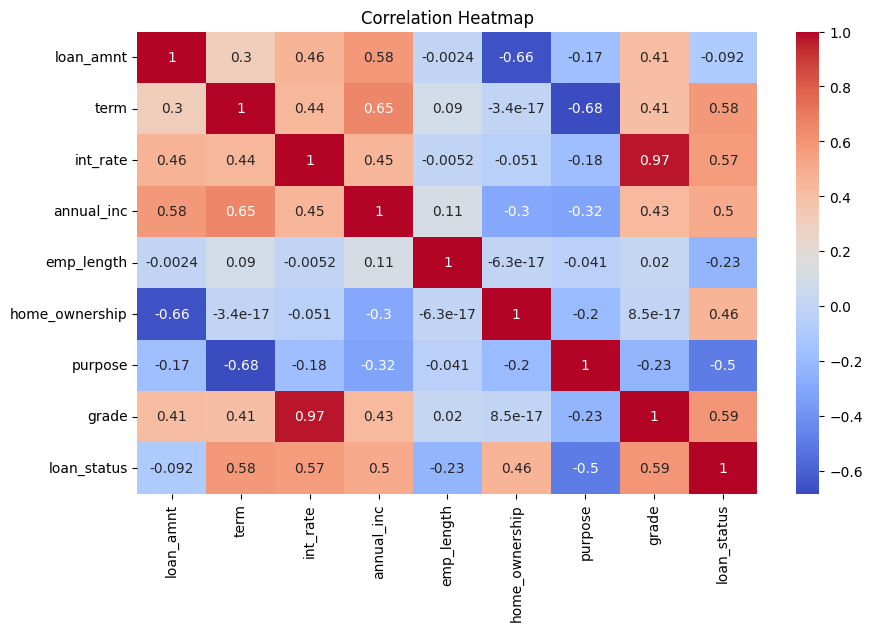


Risk Category Counts:
risk_category
Medium Risk    7
High Risk      2
Low Risk       1
Name: count, dtype: int64

Model Evaluation
R2 Score: -16.845194038587035
Mean Absolute Error: 2918.004804494313

Actual vs Predicted Loan Amount
   Actual    Predicted
0    4000  5683.837228
1    2500  6652.172381



Project Completed Successfully
Insights:
1. High interest rates indicate higher default risk
2. Income influences loan amount approval
3. Employment length affects repayment behavior
4. Risk categories help identify potential defaulters


In [4]:
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------
# 1. EMBEDDED CSV DATASET
# --------------------------------------------

csv_data = '''
loan_amnt,term,int_rate,annual_inc,emp_length,home_ownership,purpose,grade,loan_status
5000,36 months,10.65%,24000,10 years,RENT,credit_card,B,Fully Paid
2500,60 months,15.27%,30000,1 year,RENT,car,C,Charged Off
2400,36 months,15.96%,12252,10 years,OWN,small_business,C,Fully Paid
10000,36 months,13.49%,49200,3 years,MORTGAGE,other,B,Fully Paid
3000,60 months,12.69%,80000,9 years,RENT,debt_consolidation,B,Charged Off
5000,36 months,7.90%,36000,4 years,MORTGAGE,home_improvement,A,Fully Paid
7000,36 months,18.64%,47000,2 years,RENT,medical,D,Charged Off
12000,60 months,21.28%,95000,8 years,MORTGAGE,credit_card,E,Charged Off
4000,36 months,11.14%,42000,5 years,OWN,vacation,B,Fully Paid
15000,60 months,16.29%,65000,7 years,MORTGAGE,debt_consolidation,C,Fully Paid
'''

# Load dataset
loan_data = pd.read_csv(StringIO(csv_data))

print("Dataset Loaded Successfully")

# --------------------------------------------
# 2. DISPLAY DATASET
# --------------------------------------------

print("\nFirst 5 Rows:")
print(loan_data.head())

print("\nDataset Shape:")
print(loan_data.shape)

print("\nDataset Information:")
print(loan_data.info())

# --------------------------------------------
# 3. DATA CLEANING
# --------------------------------------------

print("\nMissing Values:")
print(loan_data.isnull().sum())

# Remove percentage symbol from interest rate
loan_data['int_rate'] = loan_data['int_rate'].str.replace('%', '')
loan_data['int_rate'] = loan_data['int_rate'].astype(float)

# Convert term into integer
loan_data['term'] = loan_data['term'].str.extract('(\d+)').astype(int)

# Convert employment length into integer
loan_data['emp_length'] = loan_data['emp_length'].str.extract('(\d+)')
loan_data['emp_length'] = loan_data['emp_length'].fillna(0)
loan_data['emp_length'] = loan_data['emp_length'].astype(int)

# --------------------------------------------
# 4. CONVERT TARGET VARIABLE
# --------------------------------------------

loan_data['loan_status'] = loan_data['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

# --------------------------------------------
# 5. ENCODE CATEGORICAL VARIABLES
# --------------------------------------------

encoder = LabelEncoder()

loan_data['home_ownership'] = encoder.fit_transform(
    loan_data['home_ownership']
)

loan_data['purpose'] = encoder.fit_transform(
    loan_data['purpose']
)

loan_data['grade'] = encoder.fit_transform(
    loan_data['grade']
)

# --------------------------------------------
# 6. DESCRIPTIVE STATISTICS
# --------------------------------------------

print("\nDescriptive Statistics:")
print(loan_data.describe())

print("\nAverage Loan Amount:")
print(loan_data['loan_amnt'].mean())

print("\nAverage Annual Income:")
print(loan_data['annual_inc'].mean())

print("\nAverage Interest Rate:")
print(loan_data['int_rate'].mean())

# --------------------------------------------
# 7. DEFAULT ANALYSIS
# --------------------------------------------

print("\nLoan Status Counts:")
print(loan_data['loan_status'].value_counts())

# --------------------------------------------
# 8. VISUALIZATIONS
# --------------------------------------------

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=loan_data)
plt.title('Loan Default Distribution')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(loan_data['annual_inc'], bins=10, kde=True)
plt.title('Annual Income Distribution')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(loan_data['loan_amnt'], bins=10, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='annual_inc',
    y='loan_amnt',
    hue='loan_status',
    data=loan_data
)
plt.title('Income vs Loan Amount')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    x='loan_status',
    y='int_rate',
    data=loan_data
)
plt.title('Interest Rate vs Loan Status')
plt.show()

# Heatmap
plt.figure(figsize=(10, 6))
correlation = loan_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# --------------------------------------------
# 9. RISK ANALYSIS
# --------------------------------------------

conditions = [
    (loan_data['int_rate'] < 10),
    (loan_data['int_rate'] >= 10) & (loan_data['int_rate'] < 18),
    (loan_data['int_rate'] >= 18)
]

risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']

loan_data['risk_category'] = np.select(
    conditions,
    risk_labels,
    default='Unknown'
)

print("\nRisk Category Counts:")
print(loan_data['risk_category'].value_counts())

# --------------------------------------------
# 10. LINEAR REGRESSION MODEL
# --------------------------------------------

X = loan_data[['annual_inc', 'int_rate', 'term']]
y = loan_data['loan_amnt']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# --------------------------------------------
# 11. MODEL EVALUATION
# --------------------------------------------

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("\nModel Evaluation")
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

# --------------------------------------------
# 12. ACTUAL VS PREDICTED
# --------------------------------------------

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

print("\nActual vs Predicted Loan Amount")
print(comparison)

# --------------------------------------------
# 13. INTERACTIVE DASHBOARD
# --------------------------------------------

fig1 = px.histogram(
    loan_data,
    x='loan_amnt',
    color='risk_category',
    title='Loan Amount Distribution'
)

fig1.show()

fig2 = px.scatter(
    loan_data,
    x='annual_inc',
    y='loan_amnt',
    color='risk_category',
    title='Income vs Loan Amount'
)

fig2.show()

fig3 = px.box(
    loan_data,
    x='loan_status',
    y='int_rate',
    color='loan_status',
    title='Interest Rate vs Loan Status'
)

fig3.show()

fig4 = px.bar(
    loan_data,
    x='purpose',
    color='risk_category',
    title='Loan Purpose vs Risk Category'
)

fig4.show()

# --------------------------------------------
# 14. FINAL INSIGHTS
# --------------------------------------------

print("\nProject Completed Successfully")
print("Insights:")
print("1. High interest rates indicate higher default risk")
print("2. Income influences loan amount approval")
print("3. Employment length affects repayment behavior")
print("4. Risk categories help identify potential defaulters")